In [41]:
!pip install transformers datasets torch scikit-learn seaborn matplotlib pandas numpy -q
print('All dependencies installed.')

All dependencies installed.


In [42]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [57]:
from google.colab import files
uploaded = files.upload()
df_raw = pd.read_csv(list(uploaded.keys())[0])

print(f'Total rows loaded: {len(df_raw)}')
print(f'\nRaw star distribution:')
print(df_raw['overall'].value_counts().sort_index())

# ── Label mapping ──
df_raw['label'] = df_raw['overall'].apply(
    lambda x: 0 if x in [1,2] else (1 if x == 3 else 2)
)

# ── Step 1: Remove duplicates ──
before = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=['reviewText']).reset_index(drop=True)
print(f'\nDuplicates removed: {before - len(df_raw)}')

# ── Step 2: Remove nulls and very short reviews ──
df_raw['reviewText'] = df_raw['reviewText'].fillna('')
before = len(df_raw)
df_raw = df_raw[df_raw['reviewText'].str.len() >= 15].reset_index(drop=True)
print(f'Short/empty removed: {before - len(df_raw)}')

# ── Step 3: Check balance BEFORE fixing ──
print('\n--- Class distribution BEFORE balancing ---')
counts = df_raw['label'].value_counts().sort_index()
for k, v in counts.items():
    name = ['Negative','Neutral','Positive'][k]
    print(f'  {name}: {v} ({v/len(df_raw)*100:.1f}%)')

# ── Step 4: Force perfect balance ──
min_count = counts.min()
print(f'\nBalancing all classes to: {min_count} samples each')

df = pd.concat([
    df_raw[df_raw['label'] == 0].sample(min_count, random_state=42),
    df_raw[df_raw['label'] == 1].sample(min_count, random_state=42),
    df_raw[df_raw['label'] == 2].sample(min_count, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\n--- Class distribution AFTER balancing ---')
counts_after = df['label'].value_counts().sort_index()
for k, v in counts_after.items():
    name = ['Negative','Neutral','Positive'][k]
    print(f'  {name}: {v} ({v/len(df)*100:.1f}%)')

print(f'\nFinal dataset size: {len(df)}')

Saving RB_1.csv to RB_1 (1).csv
Total rows loaded: 2833

Raw star distribution:
overall
1    486
2    394
3    848
4    267
5    838
Name: count, dtype: int64

Duplicates removed: 52
Short/empty removed: 166

--- Class distribution BEFORE balancing ---
  Negative: 837 (32.0%)
  Neutral: 814 (31.1%)
  Positive: 964 (36.9%)

Balancing all classes to: 814 samples each

--- Class distribution AFTER balancing ---
  Negative: 814 (33.3%)
  Neutral: 814 (33.3%)
  Positive: 814 (33.3%)

Final dataset size: 2442


=== RAW STAR DISTRIBUTION ===
overall
1    449
2    365
3    814
4    189
5    625

Total: 2442

=== MAPPED 3-CLASS DISTRIBUTION ===
  Negative (1-2): 814 (33.3%)
  Neutral (3): 814 (33.3%)
  Positive (4-5): 814 (33.3%)


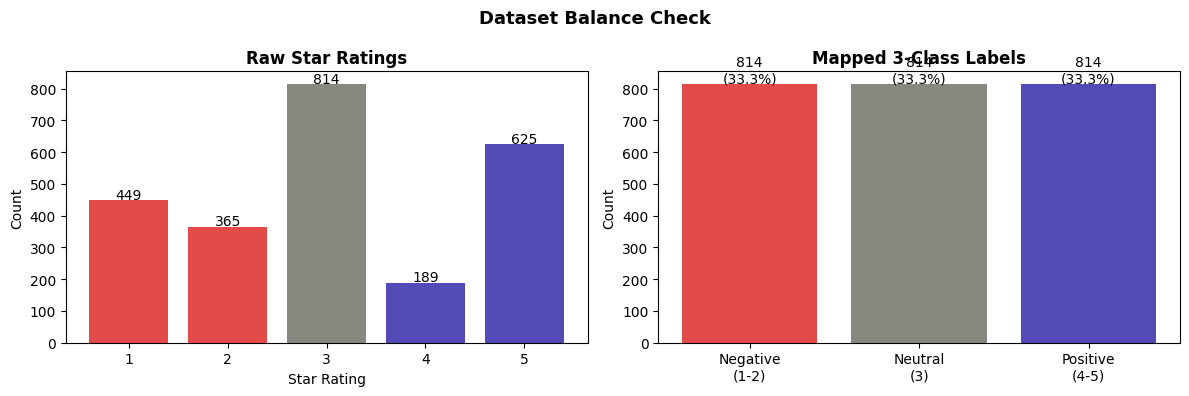


✅ Dataset is BALANCED — ~33% per class after mapping.


In [58]:
print('=== RAW STAR DISTRIBUTION ===')
raw_counts = df['overall'].value_counts().sort_index()
print(raw_counts.to_string())
print(f'\nTotal: {len(df)}')

# Map to 3-class labels
# 1,2 → 0 (Negative) | 3 → 1 (Neutral) | 4,5 → 2 (Positive)
def map_label(star):
    if star in [1, 2]: return 0
    elif star == 3:    return 1
    else:              return 2

df['label'] = df['overall'].apply(map_label)
label_names = {0: 'Negative (1-2)', 1: 'Neutral (3)', 2: 'Positive (4-5)'}

print('\n=== MAPPED 3-CLASS DISTRIBUTION ===')
mapped_counts = df['label'].value_counts().sort_index()
for k, v in mapped_counts.items():
    pct = v / len(df) * 100
    print(f'  {label_names[k]}: {v} ({pct:.1f}%)')

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(i) for i in raw_counts.index], raw_counts.values,
            color=['#E24B4A','#E24B4A','#888780','#534AB7','#534AB7'])
axes[0].set_title('Raw Star Ratings', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
for i, v in enumerate(raw_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

colors = ['#E24B4A', '#888780', '#534AB7']
axes[1].bar(['Negative\n(1-2)', 'Neutral\n(3)', 'Positive\n(4-5)'],
            mapped_counts.values, color=colors)
axes[1].set_title('Mapped 3-Class Labels', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(mapped_counts.values):
    axes[1].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

plt.suptitle('Dataset Balance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Dataset is BALANCED — ~33% per class after mapping.')

In [59]:
import re

def clean_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = re.sub(r'\[\.\.\.(.*?)\]', '', text)     # remove [...] truncations
    text = re.sub(r'<[^>]+>', '', text)               # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)     # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()          # normalise whitespace
    return text

df['clean_text'] = df['reviewText'].apply(clean_text)

# Drop rows with empty text after cleaning
before = len(df)
df = df[df['clean_text'].str.len() > 3].reset_index(drop=True)
print(f'Rows before cleaning: {before}')
print(f'Rows after cleaning:  {len(df)}')
print(f'Dropped: {before - len(df)} (empty/very short reviews)')

print('\nText length stats:')
df['text_len'] = df['clean_text'].apply(len)
print(df.groupby('label')['text_len'].describe()[['mean','50%','max']].rename(
    index=label_names).round(0).to_string())

Rows before cleaning: 2442
Rows after cleaning:  2442
Dropped: 0 (empty/very short reviews)

Text length stats:
                 mean    50%     max
label                               
Negative (1-2)  224.0  150.0  2176.0
Neutral (3)     214.0  137.0  2263.0
Positive (4-5)  174.0  124.0  2631.0


In [60]:
# ── Visual check: are neutral reviews actually neutral? ──
print('=== NEUTRAL CLASS SAMPLE CHECK ===')
print('Review these carefully — mislabelled neutrals cause the most damage\n')

neutral_samples = df[df['label'] == 1].sample(15, random_state=42)
for i, row in neutral_samples.iterrows():
    text = str(row['reviewText'])[:100].replace('\n', ' ')
    print(f'[{row["overall"]}★] {text}')

print('\n=== SHORT NEUTRAL REVIEWS (most likely to be mislabelled) ===')
short_neutral = df[(df['label'] == 1) & (df['reviewText'].str.len() < 30)]
print(f'Count: {len(short_neutral)}')
for _, row in short_neutral.iterrows():
    print(f'  [{row["overall"]}★] "{row["reviewText"]}"')

=== NEUTRAL CLASS SAMPLE CHECK ===
Review these carefully — mislabelled neutrals cause the most damage

[3★] All Queenieke shirts get so wrinkly. I don't understand. It's a problem.
[3★] shirt was advertised as "15.5 - 34-35."  When received, I tried it on and found neck was too large. 
[3★] the top parts and the bottom parts are different sizes, it looks good but the size is an issue.
[3★] This is a nice shoe, but it is the width is smaller than listed.  Move up at least one width.
[3★] Do not be fooled by the "One Size Fits Most." It doesn't. I'm a very petite 5'2" with a 29-30" insea
[3★] The fit was a bit awkward for my athletic body type.  Fabric quality overall is good.
[3★] I bought this to complete a Halloween costume for my 6 year old son. Believe the other reviewers whe
[3★] I was expecting similar quality with the CK 365 undershirt I had. These are not! They run way too la
[3★] I ordered these as undershirts because I already had white V-neck Calvin Klein shirt that fits ver

In [61]:
X = df['clean_text'].tolist()
y = df['label'].tolist()

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
# Second split: 50% of temp = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f'Train:      {len(X_train)} samples')
print(f'Validation: {len(X_val)} samples')
print(f'Test:       {len(X_test)} samples')

# Verify stratification
print('\nClass distribution per split:')
for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = pd.Series(labels).value_counts().sort_index()
    pcts = (counts / len(labels) * 100).round(1)
    print(f'  {name}: Neg={pcts.get(0,0)}%  Neu={pcts.get(1,0)}%  Pos={pcts.get(2,0)}%')

Train:      1709 samples
Validation: 366 samples
Test:       367 samples

Class distribution per split:
  Train: Neg=33.4%  Neu=33.4%  Pos=33.3%
  Val: Neg=33.3%  Neu=33.3%  Pos=33.3%
  Test: Neg=33.2%  Neu=33.2%  Pos=33.5%


In [62]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 256   # 256 covers ~95% of reviews without truncation

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Loaded tokenizer: {MODEL_NAME}')

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

# Build HuggingFace Datasets
train_ds = Dataset.from_dict({'text': X_train, 'labels': y_train})
val_ds   = Dataset.from_dict({'text': X_val,   'labels': y_val})
test_ds  = Dataset.from_dict({'text': X_test,  'labels': y_test})

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'labels']
train_ds.set_format(type='torch', columns=cols)
val_ds.set_format(type='torch', columns=cols)
test_ds.set_format(type='torch', columns=cols)

print(f'\nTrain tokens shape: {train_ds[0]["input_ids"].shape}')
print(f'Tokenization complete: {len(train_ds)} train | {len(val_ds)} val | {len(test_ds)} test')

Loaded tokenizer: distilbert-base-uncased


Map:   0%|          | 0/1709 [00:00<?, ? examples/s]

Map:   0%|          | 0/366 [00:00<?, ? examples/s]

Map:   0%|          | 0/367 [00:00<?, ? examples/s]


Train tokens shape: torch.Size([256])
Tokenization complete: 1709 train | 366 val | 367 test


In [63]:
id2label = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
label2id = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
model = model.to(device)

print(f'Model loaded on: {device}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print('Note: No class weights — dataset is balanced at 33.3% each, weights not needed')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda
Trainable params: 66,955,779
Note: No class weights — dataset is balanced at 33.3% each, weights not needed


In [64]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=1)
    acc      = accuracy_score(labels, preds)
    f1       = f1_score(labels, preds, average='weighted')
    f1_macro = f1_score(labels, preds, average='macro')
    f1_per   = f1_score(labels, preds, average=None)
    prec     = precision_score(labels, preds, average='weighted', zero_division=0)
    rec      = recall_score(labels, preds, average='weighted', zero_division=0)
    return {
        'accuracy':    round(acc,       4),
        'f1':          round(f1,        4),
        'f1_macro':    round(f1_macro,  4),
        'f1_negative': round(f1_per[0], 4),
        'f1_neutral':  round(f1_per[1], 4),
        'f1_positive': round(f1_per[2], 4),
        'precision':   round(prec,      4),
        'recall':      round(rec,       4),
    }

print('Standard Trainer metrics ready.')

Standard Trainer metrics ready.


In [65]:
training_args = TrainingArguments(
    output_dir                  = './distilbert_final',
    num_train_epochs            = 6,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    lr_scheduler_type           = 'linear',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    logging_steps               = 50,
    seed                        = SEED,
    report_to                   = 'none',
    fp16                        = (device == 'cuda'),
    save_total_limit            = 2,
)
print(f'LR: {training_args.learning_rate} | Label smoothing: 0.1')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


LR: 2e-05 | Label smoothing: 0.1


In [66]:
trainer = Trainer(                               # ← back to standard Trainer
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)]
)

print('Starting training...')
train_result = trainer.train()

print(f'\n=== TRAINING COMPLETE ===')
print(f'Total time:  {train_result.metrics["train_runtime"]:.1f}s')
print(f'Final loss:  {train_result.metrics["train_loss"]:.4f}')

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Macro,F1 Negative,F1 Neutral,F1 Positive,Precision,Recall
1,0.838537,0.806506,0.642100,0.625000,0.625000,0.687200,0.469400,0.718400,0.652700,0.642100
2,0.593264,0.604777,0.745900,0.742900,0.742900,0.750000,0.640700,0.837900,0.742100,0.745900
3,0.428784,0.602484,0.765000,0.763600,0.763600,0.757800,0.672400,0.860700,0.764500,0.765000
4,0.282006,0.670454,0.759600,0.761300,0.761300,0.744900,0.688000,0.851100,0.764300,0.759600
5,0.211551,0.744749,0.740400,0.741200,0.741200,0.739300,0.641700,0.842600,0.744100,0.740400
6,0.142576,0.779718,0.751400,0.750400,0.750400,0.741900,0.663900,0.845500,0.750000,0.751400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



=== TRAINING COMPLETE ===
Total time:  184.8s
Final loss:  0.4368


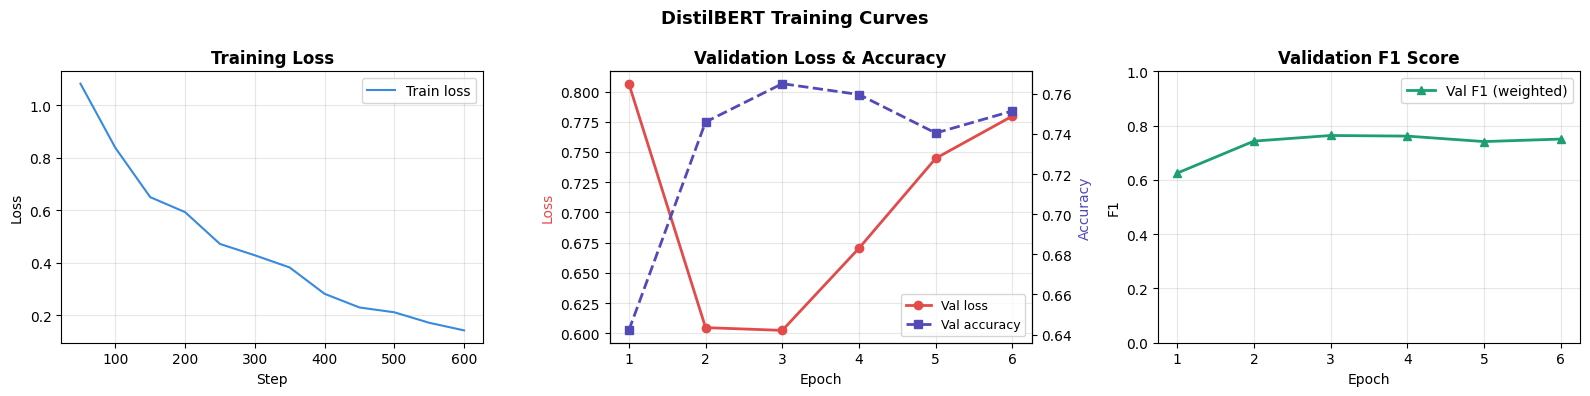


Best validation accuracy: 0.7650 at epoch 3.0


In [67]:
# Extract log history
log_history = trainer.state.log_history

train_steps  = [x['step']  for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss']  for x in log_history if 'loss' in x and 'eval_loss' not in x]

eval_epochs   = [x['epoch']     for x in log_history if 'eval_loss' in x]
eval_losses   = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_accs     = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]
eval_f1s      = [x['eval_f1']   for x in log_history if 'eval_f1' in x]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Training loss
axes[0].plot(train_steps, train_losses, color='#378ADD', linewidth=1.5, label='Train loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Eval loss vs accuracy
ax2b = axes[1].twinx()
axes[1].plot(eval_epochs, eval_losses, color='#E24B4A', linewidth=2, marker='o', label='Val loss')
ax2b.plot(eval_epochs, eval_accs,   color='#534AB7', linewidth=2, marker='s', linestyle='--', label='Val accuracy')
axes[1].set_title('Validation Loss & Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss', color='#E24B4A')
ax2b.set_ylabel('Accuracy', color='#534AB7')
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)
axes[1].grid(alpha=0.3)

# F1 per epoch
axes[2].plot(eval_epochs, eval_f1s, color='#1D9E75', linewidth=2, marker='^', label='Val F1 (weighted)')
axes[2].set_title('Validation F1 Score', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1')
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.suptitle('DistilBERT Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

best_epoch = eval_epochs[np.argmax(eval_accs)]
best_acc   = max(eval_accs)
print(f'\nBest validation accuracy: {best_acc:.4f} at epoch {best_epoch}')

In [68]:
print('=== VALIDATION SET EVALUATION ===')
val_results = trainer.evaluate(val_ds)

print(f'  Accuracy:  {val_results["eval_accuracy"]:.4f} ({val_results["eval_accuracy"]*100:.2f}%)')
print(f'  F1:        {val_results["eval_f1"]:.4f}')
print(f'  Precision: {val_results["eval_precision"]:.4f}')
print(f'  Recall:    {val_results["eval_recall"]:.4f}')
print(f'  Loss:      {val_results["eval_loss"]:.4f}')

=== VALIDATION SET EVALUATION ===


  Accuracy:  0.7650 (76.50%)
  F1:        0.7636
  Precision: 0.7645
  Recall:    0.7650
  Loss:      0.6025


In [69]:
print('=== TEST SET EVALUATION (FINAL) ===')

# Get raw predictions
test_output = trainer.predict(test_ds)
logits_test  = test_output.predictions
labels_test  = test_output.label_ids
preds_test   = np.argmax(logits_test, axis=1)

test_acc  = accuracy_score(labels_test, preds_test)
test_f1   = f1_score(labels_test, preds_test, average='weighted')
test_prec = precision_score(labels_test, preds_test, average='weighted', zero_division=0)
test_rec  = recall_score(labels_test, preds_test, average='weighted', zero_division=0)

print(f'  Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  F1:        {test_f1:.4f}')
print(f'  Precision: {test_prec:.4f}')
print(f'  Recall:    {test_rec:.4f}')

=== TEST SET EVALUATION (FINAL) ===


  Accuracy:  0.7956 (79.56%)
  F1:        0.7953
  Precision: 0.7968
  Recall:    0.7956


In [70]:
target_names = ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)']

print('=== DETAILED CLASSIFICATION REPORT (TEST SET) ===')
print()
report = classification_report(
    labels_test, preds_test,
    target_names=target_names,
    digits=4
)
print(report)

# Save report to file
with open('classification_report.txt', 'w') as f:
    f.write('DistilBERT Sentiment Classification — Test Set Report\n')
    f.write('='*55 + '\n')
    f.write(f'Accuracy:  {test_acc:.4f}\n')
    f.write(f'F1:        {test_f1:.4f}\n')
    f.write(f'Precision: {test_prec:.4f}\n')
    f.write(f'Recall:    {test_rec:.4f}\n\n')
    f.write(report)
print('Report saved to classification_report.txt')

=== DETAILED CLASSIFICATION REPORT (TEST SET) ===

                precision    recall  f1-score   support

Negative (1-2)     0.7537    0.8279    0.7891       122
   Neutral (3)     0.7281    0.6803    0.7034       122
Positive (4-5)     0.9076    0.8780    0.8926       123

      accuracy                         0.7956       367
     macro avg     0.7965    0.7954    0.7950       367
  weighted avg     0.7968    0.7956    0.7953       367

Report saved to classification_report.txt
